In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


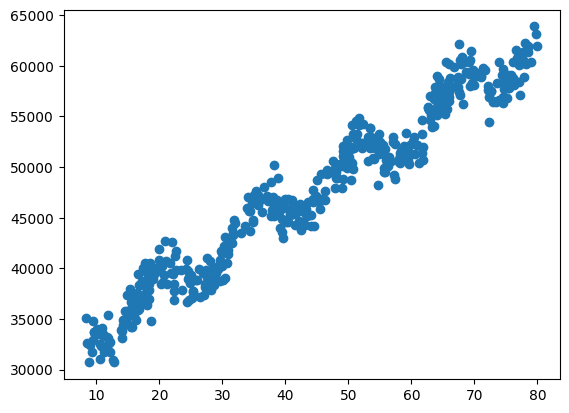

In [3]:
rng = np.random.default_rng(42)
n = 500

df = pd.DataFrame({
    "age": rng.uniform(8, 80, n)
})

noise = rng.normal(0, 1200, n)

df["target"] = (
    30_000
    + 400 * df["age"]
    + 300 * np.sin(df["age"] / 5)
    + 2000 * np.sin(df["age"] / 2.5)
    + noise
)

plt.scatter(df["age"], df["target"])

In [4]:
X = df.drop(columns="target")
y = df["target"]

In [5]:
p = int(len(df)*0.75)
X_train, y_train = X[0:p], y[0:p]
X_test, y_test = X[p:], y[p:]

print(X_train.shape, y_train.shape, X_test.shape , y_test.shape)

(375, 1) (375,) (125, 1) (125,)


In [6]:
def r2_score(y, y_pred):
    return 1 - ((np.sum((y - y_pred)**2)) / (np.sum((y - np.mean(y))**2)))
    

In [7]:
def poly_features(X, degree):
    X = np.array(X)
    
    n_features = X.shape[1]

    for i in range(n_features):
        for d in range(2, degree + 1):
            X = np.column_stack([
                X,
                X[:, i] ** d
            ])

    return X

In [8]:
class LinearRegression():
    def __init__(self, lr=0.001, degree=None):
        self.w = None
        self.b = None
        self.lr = lr
        self.costs = []
        self.acc = []
        self.degree = degree
        
    def poly_features(self, X, degree):
        X = np.array(X)
        
        n_features = X.shape[1]

        for i in range(n_features):
            for d in range(2, degree + 1):
                X = np.column_stack([
                    X,
                    X[:, i] ** d
                ])

        return X
        
    def cf_fit(self, X_train, y_train):
        if self.degree is not None:
            X_train = self.poly_features(X_train, self.degree)
        self.w = (np.linalg.inv(X_train.T @ X_train)) @ (X_train.T @ y_train)
        self.b = np.mean((y_train - (X_train @ self.w)))
        
    def predict(self, X):
        if self.degree is not None:
            X = self.poly_features(
                X,
                self.degree
            )
        return X @ self.w + self.b
    
    def compute_costs(self, y_pred, y_train):
        m = len(y_train)
        return np.sum((y_train - y_pred)**2)/(2*m)
    
    def backward(self, X_train, y_train, y_pred):
        m = len(X_train)
        self.dw = -(X_train.T @ (y_train - y_pred)) / m
        self.db = -np.mean(y_train - y_pred)
    
    def gd_fit(self, X_train, y_train, epochs):
        if self.degree is not None:
            X_train = self.poly_features(
                X_train,
                self.degree
            )
        self.w = np.zeros(X_train.shape[1])
        self.b = 0
        for epoch in range(epochs):
            y_pred = X_train @ self.w + self.b
            cost = self.compute_costs(y_pred, y_train)
            self.costs.append(cost)
            acc = r2_score(y_train, y_pred)
            self.acc.append(acc)
            self.backward(X_train, y_train, y_pred)
            
            self.w -= self.lr * self.dw
            self.b -= self.lr * self.db

            if epoch%100 == 0:
                print(f"loss: {self.compute_costs(y_pred, y_train)}    |    r2: {r2_score(y_train, y_pred)}")
    
    

In [9]:
mean = X_train.mean()
std = X_train.std()

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

X_test

,age
375,18.640403
376,75.401177
377,39.529091
378,35.599027
379,60.537371
...,...
495,47.538396
496,39.062110
497,53.072899
498,33.967328


In [10]:
model = LinearRegression(lr=0.01, degree=6)

model.gd_fit(
    X_train_scaled,
    y_train,
    epochs=1000
)

y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))

loss: 1153356080.730517    |    r2: -31.66591613036735
loss: 145399889.68296352    |    r2: -3.118086930048541
loss: 51648227.64273575    |    r2: -0.46280641394903976
loss: 29782783.12802234    |    r2: 0.156477420942984
loss: 19988306.40262669    |    r2: 0.4338813906259297
loss: 14010897.835003646    |    r2: 0.6031764853578538
loss: 10074002.876634864    |    r2: 0.714679153677499
loss: 7438595.727496557    |    r2: 0.7893204464589926
loss: 5666781.758680436    |    r2: 0.8395026299762475
loss: 4473287.461069495    |    r2: 0.8733053603551755
Train R2: 0.8961071186678491
Test R2: 0.8766347385046779


In [11]:
print("w shape:", model.w.shape)
print("b:", model.b)
print("first cost:", model.costs[0])
print("last cost:", model.costs[-1])

w shape: (6,)
b: 43960.4277511185
first cost: 1153356080.730517
last cost: 3674797.3326486717


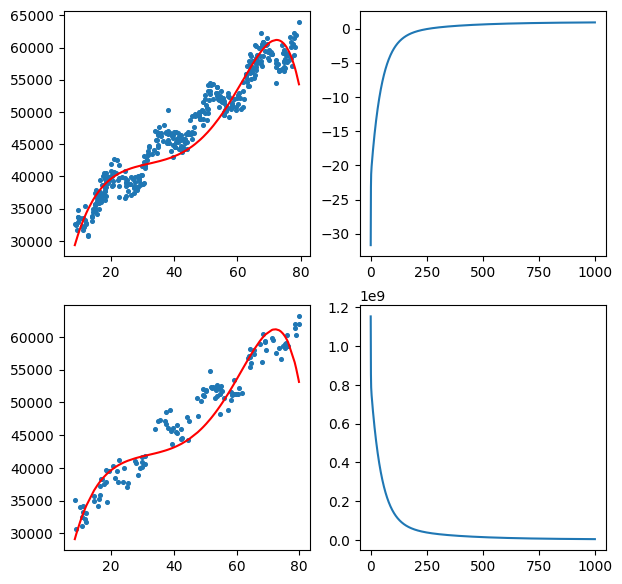

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(7, 7))

idx = np.argsort(X_train.iloc[:, 0].values)
idx_t = np.argsort(X_test.iloc[:, 0].values)

axs[0,0].scatter(X_train.iloc[:, 0], y_train, s=7)
axs[0,0].plot(
    X_train.iloc[idx, 0],
    np.asarray(y_pred_train).ravel()[idx],
    color="red"
)

axs[0,1].plot(model.acc)

axs[1,0].scatter(X_test.iloc[:, 0], y_test, s=7)
axs[1,0].plot(
    X_test.iloc[idx_t, 0],
    np.asarray(y_pred_test).ravel()[idx_t],
    color="red"
)

axs[1,1].plot(model.costs)

plt.show()